# Notebook 15 v4 — Reconstrucción final de figuras del manuscrito de invarianza

**Objetivo:** regenerar únicamente las figuras que requieren corrección editorial, sin reentrenar modelos ni modificar resultados.

En esta versión, la antigua **Figure 1** se reconstruye como **dos gráficos individuales**:

- **Figure 1A** — matriz de correlación de Spearman para Dry Bean.
- **Figure 1B** — matriz de correlación de Spearman para INIAP Rice.

Además se reconstruyen:

- **Figure 6** — resultados de predicción conformal APS usando puntos.
- **Figure 7** — sensibilidad del modelo R1 a perturbaciones coherentes de escala, con 0.02 mostrado únicamente como referencia descriptiva.

Las figuras se exportan en **PNG 600 dpi, TIFF 600 dpi, PDF y SVG**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

PROJECT_ROOT = Path('/content/drive/MyDrive/Grain_Robustness_Q1')
if not PROJECT_ROOT.exists():
    candidates = list(Path('/content/drive/MyDrive').rglob('Grain_Robustness_Q1'))
    if not candidates:
        raise FileNotFoundError('No se encontró Grain_Robustness_Q1 en Google Drive.')
    PROJECT_ROOT = candidates[0]

OUTPUT = PROJECT_ROOT / 'NOTEBOOK15_FIGURE_REBUILD_OUTPUTS_V3'
FIGDIR = OUTPUT / 'figures'
TABLEDIR = OUTPUT / 'tables'
for p in [OUTPUT, FIGDIR, TABLEDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT       =', OUTPUT)


Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/Grain_Robustness_Q1
OUTPUT       = /content/drive/MyDrive/Grain_Robustness_Q1/NOTEBOOK15_FIGURE_REBUILD_OUTPUTS_V3


In [2]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'savefig.dpi': 600,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

BLUE = '#1F4E79'
ORANGE = '#C55A11'
GRAY = '#666666'


def newest_match(filename):
    matches = list(PROJECT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'No se encontró {filename} dentro de {PROJECT_ROOT}')
    matches.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    chosen = matches[0]
    print(f'{filename} -> {chosen.relative_to(PROJECT_ROOT)}')
    return chosen


def save_figure(fig, stem):
    paths = {}
    for ext in ('png', 'tiff', 'pdf', 'svg'):
        path = FIGDIR / f'{stem}.{ext}'
        kwargs = dict(bbox_inches='tight', facecolor='white')
        if ext in ('png', 'tiff'):
            kwargs['dpi'] = 600
        fig.savefig(path, **kwargs)
        paths[ext] = path
    return paths


def parse_markdown_table(path):
    lines = [x.strip() for x in Path(path).read_text(encoding='utf-8-sig').splitlines() if x.strip().startswith('|')]
    if len(lines) < 3:
        raise ValueError(f'No se reconoció una tabla Markdown en {path}')
    header = [x.strip() for x in lines[0].strip('|').split('|')]
    rows = []
    for line in lines[2:]:
        vals = [x.strip() for x in line.strip('|').split('|')]
        if len(vals) == len(header):
            rows.append(vals)
    return pd.DataFrame(rows, columns=header)

manifest = []


## Figure 1A y Figure 1B — Correlaciones de Spearman como gráficos individuales

Table_main_spearman_dry_bean_training.csv -> NOTEBOOK14_MINOR_REVISION_OUTPUTS/09_tables/main/Table_main_spearman_dry_bean_training.csv
Table_main_spearman_iniap_rice_training.csv -> NOTEBOOK14_MINOR_REVISION_OUTPUTS/09_tables/main/Table_main_spearman_iniap_rice_training.csv


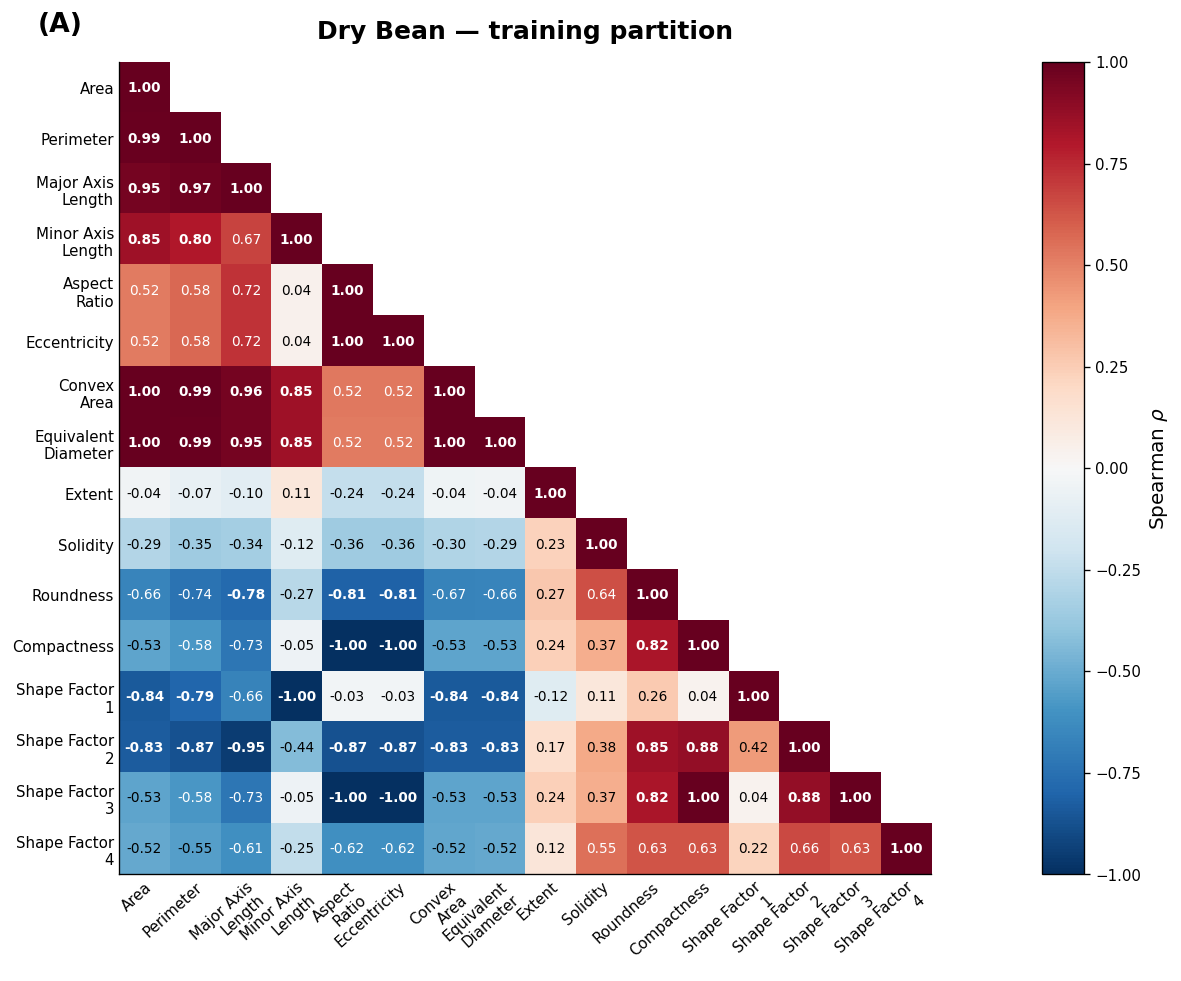

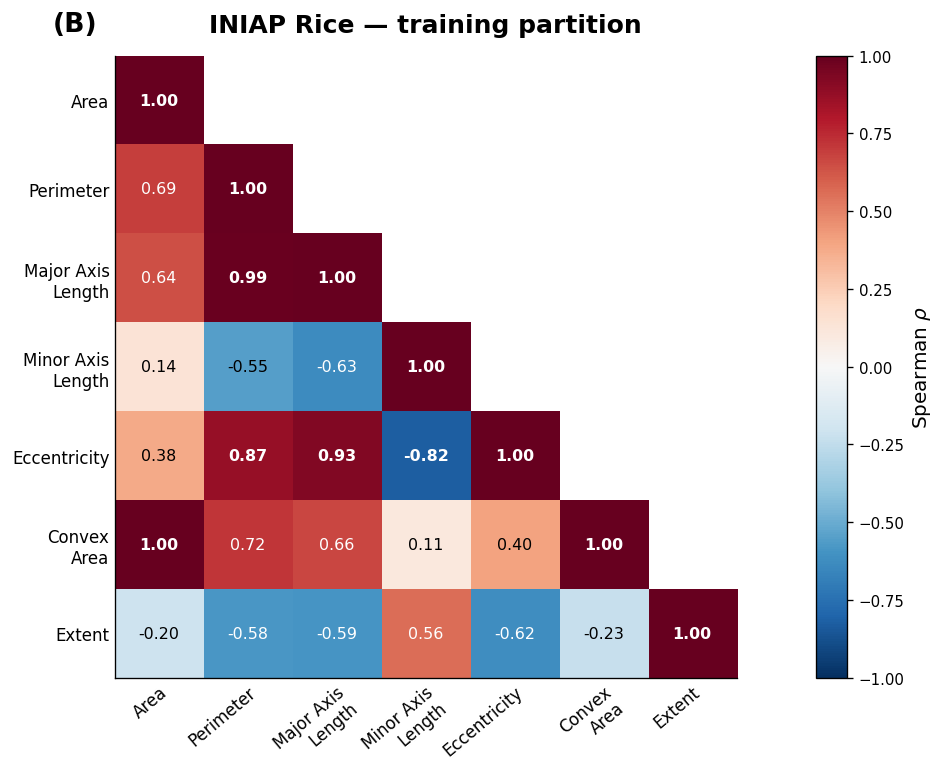

In [3]:
db_path = newest_match('Table_main_spearman_dry_bean_training.csv')
rice_path = newest_match('Table_main_spearman_iniap_rice_training.csv')

db = pd.read_csv(db_path, index_col=0)
rice = pd.read_csv(rice_path, index_col=0)

DISPLAY = {
    'Area':'Area', 'AREA':'Area',
    'Perimeter':'Perimeter', 'PERIMETER':'Perimeter',
    'MajorAxisLength':'Major Axis Length', 'MAJOR_AXIS':'Major Axis Length',
    'MinorAxisLength':'Minor Axis Length', 'MINOR_AXIS':'Minor Axis Length',
    'AspectRation':'Aspect Ratio', 'AspectRatio':'Aspect Ratio',
    'Eccentricity':'Eccentricity', 'ECCENTRICITY':'Eccentricity',
    'ConvexArea':'Convex Area', 'CONVEX_AREA':'Convex Area',
    'EquivDiameter':'Equivalent Diameter',
    'Extent':'Extent', 'EXTENT':'Extent',
    'Solidity':'Solidity',
    'roundness':'Roundness', 'Roundness':'Roundness',
    'Compactness':'Compactness',
    'ShapeFactor1':'Shape Factor 1', 'ShapeFactor2':'Shape Factor 2',
    'ShapeFactor3':'Shape Factor 3', 'ShapeFactor4':'Shape Factor 4',
}

def pretty_label(x):
    return DISPLAY.get(x, x.replace('_', ' ').title())


def wrap_label(x):
    x = pretty_label(x)
    replacements = {
        'Major Axis Length':'Major Axis\nLength',
        'Minor Axis Length':'Minor Axis\nLength',
        'Equivalent Diameter':'Equivalent\nDiameter',
        'Shape Factor 1':'Shape Factor\n1',
        'Shape Factor 2':'Shape Factor\n2',
        'Shape Factor 3':'Shape Factor\n3',
        'Shape Factor 4':'Shape Factor\n4',
        'Aspect Ratio':'Aspect\nRatio',
        'Convex Area':'Convex\nArea',
    }
    return replacements.get(x, x)


def single_correlation_figure(df, title, panel_label, stem, figsize=(9.8, 8.8), xrot=42, ann_fs=8.2, tick_fs=9):
    vals = df.to_numpy(float)
    n = len(df)
    mask = np.triu(np.ones_like(vals, dtype=bool), k=1)
    plot = np.ma.array(vals, mask=mask)
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[22, 1], wspace=0.12)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    im = ax.imshow(plot, cmap='RdBu_r', norm=norm, aspect='equal')
    labels = [wrap_label(x) for x in df.index]
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=xrot, ha='right', rotation_mode='anchor', fontsize=tick_fs)
    ax.set_yticklabels(labels, fontsize=tick_fs)
    ax.tick_params(axis='both', length=0, pad=3)
    ax.set_title(title, fontsize=15, fontweight='semibold', pad=14)
    ax.text(-0.10, 1.03, panel_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom')

    for i in range(n):
        for j in range(i + 1):
            v = vals[i, j]
            rgba = im.cmap(im.norm(v))
            lum = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
            color = 'black' if lum > 0.57 else 'white'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=ann_fs,
                    color=color, fontweight='semibold' if abs(v) >= 0.75 else 'normal')

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'Spearman $\rho$', fontsize=12)
    cbar.ax.tick_params(labelsize=9)

    fig.subplots_adjust(left=0.12, right=0.92, bottom=0.18, top=0.90)
    paths = save_figure(fig, stem)
    plt.show()
    plt.close(fig)
    return paths

paths = single_correlation_figure(
    db,
    'Dry Bean — training partition',
    '(A)',
    'Figure_1A_training_spearman_correlation_dry_bean_FINAL',
    figsize=(10.6, 9.4),
    xrot=42,
    ann_fs=8.2,
    tick_fs=9,
)
for ext, path in paths.items():
    manifest.append({'figure':'Figure 1A','format':ext,'path':str(path.relative_to(PROJECT_ROOT))})

paths = single_correlation_figure(
    rice,
    'INIAP Rice — training partition',
    '(B)',
    'Figure_1B_training_spearman_correlation_iniap_rice_FINAL',
    figsize=(8.0, 7.2),
    xrot=40,
    ann_fs=9.5,
    tick_fs=10,
)
for ext, path in paths.items():
    manifest.append({'figure':'Figure 1B','format':ext,'path':str(path.relative_to(PROJECT_ROOT))})


## Figure 6 — Predicción conformal APS con puntos

03_primary_conformal_results_v2.csv -> NOTEBOOK08_V2_CANONICAL_CONFORMAL_OUTPUTS/07_results/08_V2_CANONICAL_CONFORMAL/03_primary_conformal_results_v2.csv


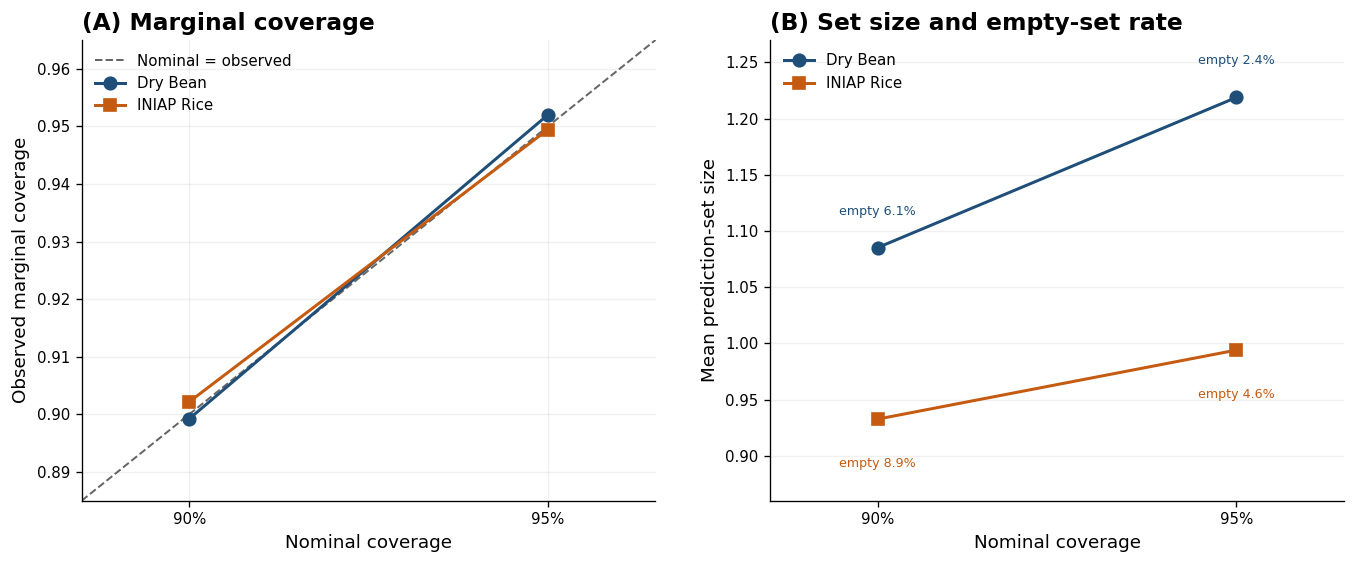

In [4]:
conf_path = newest_match('03_primary_conformal_results_v2.csv')
conf = pd.read_csv(conf_path, encoding='utf-8-sig')
conf = conf[(conf['method'].astype(str).str.upper() == 'APS') &
            (conf['calibration_mode'].astype(str).str.lower() == 'marginal')].copy()
name_map = {'dry_bean':'Dry Bean', 'iniap_rice':'INIAP Rice'}
conf['dataset'] = conf['dataset_id'].map(name_map)
required = ['dataset','nominal_coverage','coverage','mean_set_size','empty_set_rate']

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.8))
style = {'Dry Bean': dict(color=BLUE, marker='o'), 'INIAP Rice': dict(color=ORANGE, marker='s')}

ax = axes[0]
lo, hi = 0.885, 0.965
ax.plot([lo, hi], [lo, hi], '--', color=GRAY, lw=1.2, label='Nominal = observed')
for ds in ['Dry Bean', 'INIAP Rice']:
    d = conf[conf['dataset'] == ds].sort_values('nominal_coverage')
    ax.plot(d['nominal_coverage'], d['coverage'], lw=1.8, ms=7.5, label=ds, **style[ds])
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xticks([0.90, 0.95])
ax.set_xticklabels(['90%', '95%'])
ax.set_yticks(np.arange(0.89, 0.961, 0.01))
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Observed marginal coverage')
ax.grid(alpha=0.18)
ax.set_title('(A) Marginal coverage', loc='left', fontweight='bold')
ax.legend(frameon=False, loc='upper left')

ax = axes[1]
for ds in ['Dry Bean', 'INIAP Rice']:
    d = conf[conf['dataset'] == ds].sort_values('nominal_coverage')
    ax.plot(d['nominal_coverage'], d['mean_set_size'], lw=1.8, ms=7.5, label=ds, **style[ds])
    for _, row in d.iterrows():
        offset = 18 if ds == 'Dry Bean' else -23
        va = 'bottom' if offset > 0 else 'top'
        ax.annotate(f"empty {100*row['empty_set_rate']:.1f}%",
                    (row['nominal_coverage'], row['mean_set_size']),
                    xytext=(0, offset), textcoords='offset points',
                    ha='center', va=va, fontsize=7.6,
                    color=style[ds]['color'])
ax.set_xlim(lo, hi)
ax.set_xticks([0.90, 0.95])
ax.set_xticklabels(['90%', '95%'])
ax.set_ylim(0.86, 1.27)
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Mean prediction-set size')
ax.grid(axis='y', alpha=0.18)
ax.set_title('(B) Set size and empty-set rate', loc='left', fontweight='bold')
ax.legend(frameon=False, loc='upper left')

fig.tight_layout(w_pad=2.7)
paths = save_figure(fig, 'Figure_6_conformal_APS_points_FINAL')
plt.show()
plt.close(fig)
conf[required].to_csv(TABLEDIR/'Figure_6_source_values.csv', index=False)
for ext, path in paths.items():
    manifest.append({'figure':'Figure 6','format':ext,'path':str(path.relative_to(PROJECT_ROOT))})


## Figure 7 — Sensibilidad coherente de escala R1

Table_S21_complete_R1_scale_sensitivity.md -> NOTEBOOK13B_RECONCILED_FINAL_MANUSCRIPT_ASSETS/09_tables/supplementary/Table_S21_complete_R1_scale_sensitivity.md


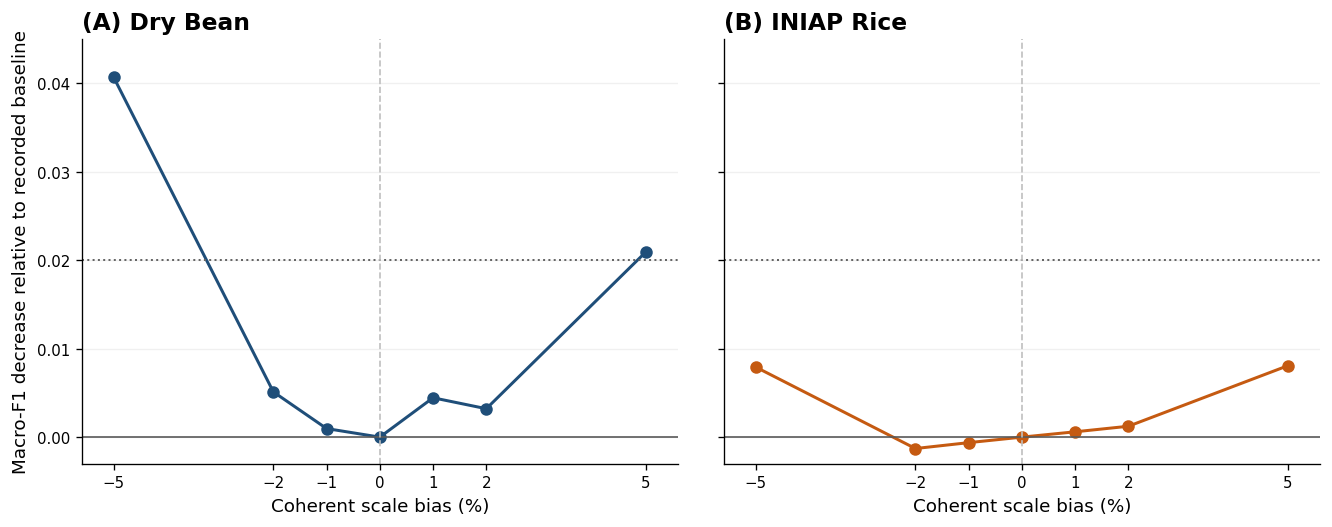

In [5]:
scale_path = newest_match('Table_S21_complete_R1_scale_sensitivity.md')
scale = parse_markdown_table(scale_path)
for c in ['relative_scale_bias','scale_bias_percent','macro_f1','macro_f1_drop','accuracy','mcc','label_flip_rate']:
    scale[c] = pd.to_numeric(scale[c], errors='coerce')
scale['dataset'] = scale['dataset_id'].map({'dry_bean':'Dry Bean','iniap_rice':'INIAP Rice'})
scale = scale[scale['representation'].eq('R1_full_native')].copy()

ymin = min(-0.003, scale['macro_f1_drop'].min() - 0.001)
ymax = max(0.045, scale['macro_f1_drop'].max() + 0.003)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5), sharey=True)
for ax, ds, panel, color in [(axes[0], 'Dry Bean', '(A)', BLUE), (axes[1], 'INIAP Rice', '(B)', ORANGE)]:
    d = scale[scale['dataset'] == ds].sort_values('scale_bias_percent')
    ax.plot(d['scale_bias_percent'], d['macro_f1_drop'], marker='o', ms=6.5, lw=1.8, color=color)
    ax.axhline(0, color='0.35', lw=1.0)
    ax.axhline(0.02, color='0.40', lw=1.2, ls=':')
    ax.axvline(0, color='0.75', lw=1.0, ls='--')
    ax.set_xlim(-5.6, 5.6)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([-5,-2,-1,0,1,2,5])
    ax.set_xlabel('Coherent scale bias (%)')
    ax.grid(axis='y', alpha=0.18)
    ax.set_title(f'{panel} {ds}', loc='left', fontweight='bold')
axes[0].set_ylabel('Macro-F1 decrease relative to recorded baseline')
fig.tight_layout(w_pad=2.4)
paths = save_figure(fig, 'Figure_7_R1_coherent_scale_sensitivity_FINAL')
plt.show()
plt.close(fig)
scale[['dataset','scale_bias_percent','macro_f1','macro_f1_drop','accuracy','label_flip_rate']].to_csv(TABLEDIR/'Figure_7_source_values.csv', index=False)
for ext, path in paths.items():
    manifest.append({'figure':'Figure 7','format':ext,'path':str(path.relative_to(PROJECT_ROOT))})


## Captions propuestas y validación

In [6]:
captions = {
    'Figure 1A': 'Figure 1A. Training-only Spearman correlation matrix for the native R1 predictors in Dry Bean. Only the lower triangle is shown; cell annotations report Spearman rho. Predictor names are standardized for display.',
    'Figure 1B': 'Figure 1B. Training-only Spearman correlation matrix for the native R1 predictors in INIAP Rice. Only the lower triangle is shown; cell annotations report Spearman rho. Predictor names are standardized for display.',
    'Figure 6': 'Figure 6. Canonical randomized marginal APS results for the selected models: (A) observed marginal coverage plotted as points against nominal coverage, with the dashed diagonal indicating equality; and (B) point estimates of mean prediction-set size, with the corresponding empty-set rate annotated for each dataset and nominal level.',
    'Figure 7': 'Figure 7. Macro-F1 decrease under a fixed +/-5% local morphometric-scale stress range for the native R1 models: (A) Dry Bean and (B) INIAP Rice. The dotted 0.02 line is a descriptive visual reference only; it was not used as a formal inferential or model-selection threshold.'
}
(OUTPUT/'FIGURE_CAPTIONS_FINAL.txt').write_text('\n\n'.join(f'{k}\n{v}' for k, v in captions.items()), encoding='utf-8')
pd.DataFrame(manifest).to_csv(OUTPUT/'figure_manifest.csv', index=False)
expected = [
    FIGDIR/'Figure_1A_training_spearman_correlation_dry_bean_FINAL.png',
    FIGDIR/'Figure_1B_training_spearman_correlation_iniap_rice_FINAL.png',
    FIGDIR/'Figure_6_conformal_APS_points_FINAL.png',
    FIGDIR/'Figure_7_R1_coherent_scale_sensitivity_FINAL.png',
]
validation = []
for p in expected:
    validation.append({'file': p.name, 'exists': p.exists(), 'size_bytes': p.stat().st_size if p.exists() else 0, 'valid_size': p.exists() and p.stat().st_size > 10000})
val = pd.DataFrame(validation)
val.to_csv(OUTPUT/'final_validation.csv', index=False)
display(val)
assert val['exists'].all() and val['valid_size'].all(), 'Falló la validación.'
zip_path = shutil.make_archive(str(PROJECT_ROOT/'NOTEBOOK15_FIGURE_REBUILD_OUTPUTS_V3'), 'zip', root_dir=OUTPUT)
print('Carpeta:', OUTPUT)
print('ZIP    :', zip_path)


,file,exists,size_bytes,valid_size
0,Figure_1A_training_spearman_correlation_dry_be...,True,1178401,True
1,Figure_1B_training_spearman_correlation_iniap_...,True,583094,True
2,Figure_6_conformal_APS_points_FINAL.png,True,601349,True
3,Figure_7_R1_coherent_scale_sensitivity_FINAL.png,True,370635,True


Carpeta: /content/drive/MyDrive/Grain_Robustness_Q1/NOTEBOOK15_FIGURE_REBUILD_OUTPUTS_V3
ZIP    : /content/drive/MyDrive/Grain_Robustness_Q1/NOTEBOOK15_FIGURE_REBUILD_OUTPUTS_V3.zip
